# Union2.1 analysis: MCMC constraints on $(\Omega_m, \Omega_\Lambda)$

Orchestrates milestones 3 and 4 with the tested `cosmo_library` only. Flatness is not imposed ($\Omega_k$ is derived), $M$ is marginalized analytically, and diagnostics use unthinned chains.

## 1. Setup

In [23]:
%matplotlib widget
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from cosmo_library.data import Union21
from cosmo_library.likelihood import make_union21_posterior
from cosmo_library.bayes import (
    GaussianRandomWalk, MetropolisHastings, scaled_proposal_cov, dispersed_starts,
)
from cosmo_library import diagnostics as dg
from cosmo_library.postprocess import credible_interval, contour_levels_2d

# repo root (works from ./ or ./notebooks)
ROOT = Path.cwd()
if not (ROOT / "union_data").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "union_data").is_dir(), "union_data/ nao encontrado"
FIG_DIR = ROOT / "notebooks" / "figures"

CHAIN_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#c2408f"]   # one per chain
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.labelsize": 11, "legend.frameon": False, "legend.fontsize": 9,
})

PARAM_NAMES = ["Omega_m", "Omega_Lambda"]
PARAM_LABELS = [r"$\Omega_m$", r"$\Omega_\Lambda$"]
FIGURES = {}

In [24]:
data = Union21(str(ROOT / "union_data"))

print(f"n (SNe after cuts) = {data.n}")
print(f"z   : {data.z.shape}")
print(f"mu  : {data.mu.shape}")
print(f"cov : {data.cov.shape}")
print(f"redshift: {data.z.min():.3f} <= z <= {data.z.max():.3f}")
assert data.n == 580

n (SNe after cuts) = 580
z   : (580,)
mu  : (580,)
cov : (580, 580)
redshift: 0.015 <= z <= 1.414


## 2. Posterior

We define a uniform box prior: $\;\;0\le\Omega_m\le2\;\;$, $\;\;-1\le\Omega_\Lambda\le3\;\;$.
 Points outside the prior, or with an invalid cosmology ($E^2<0$), must give `log_prob = -inf`.

In [25]:
H0 = 70.0                                   # degenerate with the marginalized M
BOUNDS = ((0.0, 2.0), (-1.0, 3.0))          # Omega_m, Omega_Lambda priors

posterior = make_union21_posterior(data, H0=H0, bounds=BOUNDS)

lp_ref = posterior.log_prob([0.3, 0.7])
print(f"log_prob(0.3, 0.7)          = {lp_ref:.3f}")
assert np.isfinite(lp_ref)

for theta in ([2.5, 0.7], [0.3, 3.5], [-0.1, 0.7], [0.3, -1.5]):
    lp = posterior.log_prob(theta)
    print(f"log_prob{tuple(theta)!s:<14} = {lp}   (outside prior)")
    assert lp == -np.inf

# inside the prior but E^2(z) < 0 -> NaN distance -> -inf
lp_bad = posterior.log_prob([0.1, 3.0])
print(f"log_prob(0.1, 3.0)          = {lp_bad}   (inside prior, E^2<0)")
assert lp_bad == -np.inf

log_prob(0.3, 0.7)          = -275.254
log_prob(2.5, 0.7)     = -inf   (outside prior)
log_prob(0.3, 3.5)     = -inf   (outside prior)
log_prob(-0.1, 0.7)    = -inf   (outside prior)
log_prob(0.3, -1.5)    = -inf   (outside prior)
log_prob(0.1, 3.0)          = -inf   (inside prior, E^2<0)


## 3. Proposal tuning (warm-up)

Proposal covariance was $(2.4^2 / d) \cdot \hat\Sigma$ estimated from a warm-up chain (two rounds; regularized before the Cholesky factorization). The warm-up is discarded and the covariance is **frozen** before sampling.

In [42]:
SEED_WARMUP = 7
N_WARMUP = 20000
N_DISCARD_TUNE = 2000
N_TUNE_ROUNDS = 5

cov = np.diag([0.05**2, 0.10**2]) # initial proposal covariance (Cholesky method)
x_warm = np.array([0.3, 0.7])

for k in range(N_TUNE_ROUNDS):
    mh_warm = MetropolisHastings(posterior, GaussianRandomWalk(cov))
    res_w = mh_warm.sample(x_warm, N_WARMUP, rng=np.random.default_rng(SEED_WARMUP + k))
    kept = res_w.samples[N_DISCARD_TUNE:]
    print(f"round {k}: acceptance = {res_w.acceptance_rate:.3f}   "
          f"sample std = {kept.std(axis=0).round(3)}")
    cov = scaled_proposal_cov(kept)
    x_warm = res_w.samples[-1]

# FREEZE: the proposal must not change after this point
PROPOSAL_COV = cov.copy()
PROPOSAL_COV.setflags(write=False)

print("\nfrozen PROPOSAL_COV:\n", PROPOSAL_COV)
print("warm-up discarded: none of its samples is reused")

round 0: acceptance = 0.629   sample std = [0.118 0.218]
round 1: acceptance = 0.343   sample std = [0.113 0.211]
round 2: acceptance = 0.346   sample std = [0.111 0.209]
round 3: acceptance = 0.355   sample std = [0.114 0.213]
round 4: acceptance = 0.350   sample std = [0.111 0.209]

frozen PROPOSAL_COV:
 [[0.03535853 0.05602305]
 [0.05602305 0.12547732]]
warm-up discarded: none of its samples is reused


## 4. Dispersed chains

`N_CHAINS` chains from well-separated valid starts (`dispersed_starts`), each with its own explicit seed and a discarded burn-in. Retained chains are unthinned, shape `(n_chains, n_steps, 2)`.

In [27]:
N_CHAINS = 5
N_BURN = 3000
N_STEPS = 30000
SEED_STARTS = 2024
SEEDS = [101, 102, 103, 104, 105]
assert len(SEEDS) == N_CHAINS
assert len(CHAIN_COLORS) >= N_CHAINS, "add more entries to CHAIN_COLORS (section 1)"

starts = dispersed_starts(posterior, BOUNDS, N_CHAINS, rng=np.random.default_rng(SEED_STARTS))
print("starting points (Omega_m, Omega_Lambda) and log_prob:")
for i, s0 in enumerate(starts):
    print(f"  chain {i}: {s0.round(3)}   log_prob = {posterior.log_prob(s0):.1f}")

starting points (Omega_m, Omega_Lambda) and log_prob:
  chain 0: [1.948 2.706]   log_prob = -528.6
  chain 1: [ 0.109 -0.969]   log_prob = -314.3
  chain 2: [ 1.916 -0.959]   log_prob = -460.1
  chain 3: [0.618 1.805]   log_prob = -318.4
  chain 4: [1.529 0.91 ]   log_prob = -356.7


In [43]:
sampler = MetropolisHastings(posterior, GaussianRandomWalk(PROPOSAL_COV))

results = [
    sampler.sample(x0, N_BURN + N_STEPS, rng=np.random.default_rng(seed))
    for x0, seed in zip(starts, SEEDS)
]

# the frozen covariance was never modified
assert np.array_equal(sampler.proposal.cov, PROPOSAL_COV)

burn      = np.stack([r.samples[:N_BURN]   for r in results])
burn_lp   = np.stack([r.log_probs[:N_BURN] for r in results])

chains    = np.stack([r.samples[N_BURN:]   for r in results])
log_probs = np.stack([r.log_probs[N_BURN:] for r in results])
accepted  = np.stack([r.accepted[N_BURN:]  for r in results])

assert chains.shape == (N_CHAINS, N_STEPS, 2)
assert np.all(np.isfinite(log_probs))
print("chains.shape =", chains.shape, "(n_chains, n_steps, n_params), unthinned")

# burn-in check: first step at which each chain reaches the 5th percentile of the retained log_prob
thr = np.percentile(log_probs, 5)
first = [int(np.argmax(burn_lp[i] >= thr)) if np.any(burn_lp[i] >= thr) else None
         for i in range(N_CHAINS)]
print(f"step at which each chain reaches log_prob >= {thr:.1f} (5th pct of retained): {first}"
      f"   (N_BURN = {N_BURN})")

chains.shape = (5, 30000, 2) (n_chains, n_steps, n_params), unthinned
step at which each chain reaches log_prob >= -278.0 (5th pct of retained): [35, 10, 78, 28, 43]   (N_BURN = 3000)


## 5. Convergence diagnostics

All diagnostics use unthinned, post-burn-in chains and both parameters.

### 5.1 Traces and acceptance rate

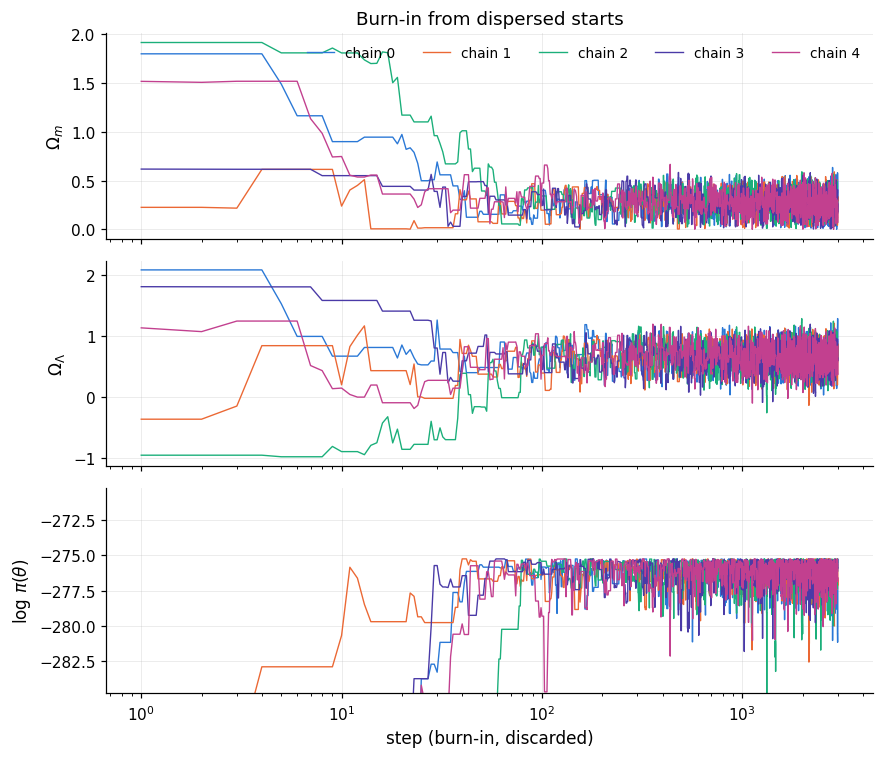

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
t = np.arange(1, N_BURN + 1)
for i in range(N_CHAINS):
    for ax, y in zip(axes, (burn[i, :, 0], burn[i, :, 1], burn_lp[i])):
        ax.plot(t, y, color=CHAIN_COLORS[i], lw=0.9, label=f"chain {i}")
for ax, lab in zip(axes, PARAM_LABELS + [r"$\log\,\pi(\theta)$"]):
    ax.set_ylabel(lab)
axes[-1].set_ylim(np.percentile(burn_lp, 2) - 5, burn_lp.max() + 5)
axes[-1].set_xscale("log")
axes[-1].set_xlabel("step (burn-in, discarded)")
axes[0].legend(ncol=N_CHAINS, loc="upper right")
axes[0].set_title("Burn-in from dispersed starts")
fig.tight_layout()
FIGURES["burnin"] = fig
plt.show()

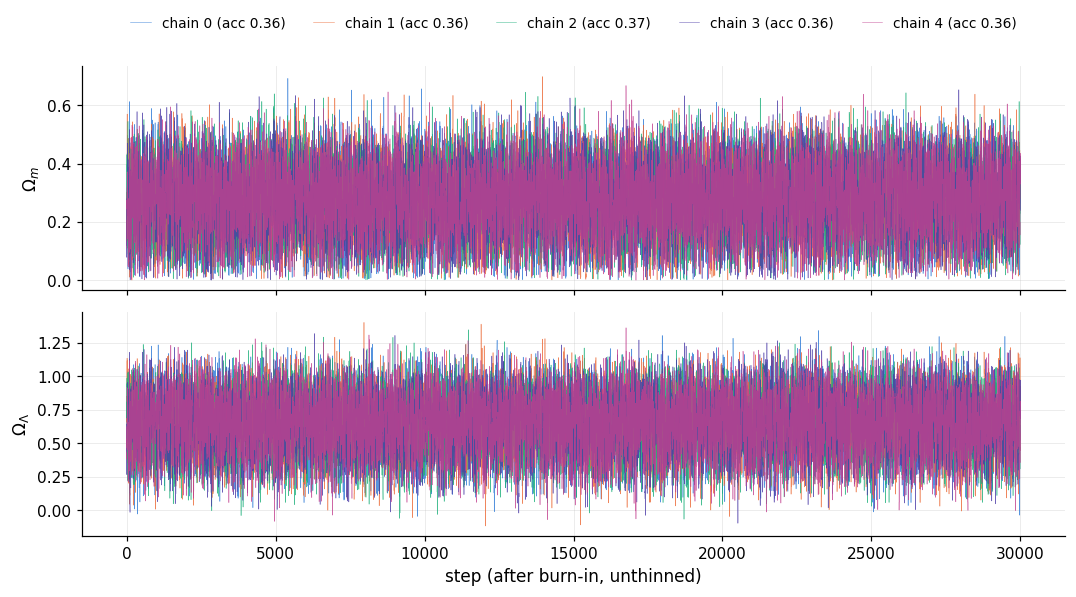

acceptance rate per chain: [0.36  0.364 0.365 0.364 0.364]
mean = 0.363  (reference: optimum ~0.35 for a Gaussian target, d=2)


In [30]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
steps = np.arange(N_STEPS)
acc = [dg.acceptance_rate(accepted[i]) for i in range(N_CHAINS)]
for p, ax in enumerate(axes):
    for i in range(N_CHAINS):
        ax.plot(steps, chains[i, :, p], color=CHAIN_COLORS[i], lw=0.35, alpha=0.8,
                label=f"chain {i} (acc {acc[i]:.2f})")
    ax.set_ylabel(PARAM_LABELS[p])
axes[0].legend(ncol=N_CHAINS, loc="upper center", bbox_to_anchor=(0.5, 1.28),
               markerscale=1, handlelength=1.5)
axes[-1].set_xlabel("step (after burn-in, unthinned)")
fig.tight_layout()
FIGURES["traces"] = fig
plt.show()

print("acceptance rate per chain:", np.round(acc, 3))
print(f"mean = {np.mean(acc):.3f}  (reference: optimum ~0.35 for a Gaussian target, d=2)")

### 5.2 Split, rank-normalized and folded $\hat R$

Rank-normalized $\hat R$ tests location differences between chains; the folded variant (on $|x-\mathrm{median}|$) tests scale/tail differences (slide 20). Guideline $\hat R<1.01$ for all three, not a guarantee.

In [31]:
rhat_split = dg.split_rhat(chains)
rhat_rank = dg.rank_normalized_rhat(chains)
rhat_fold = dg.folded_rank_normalized_rhat(chains)

print(f"{'parameter':<14}{'split-Rhat':>12}{'rank-Rhat':>12}{'folded-Rhat':>13}   < 1.01 ?")
for p, name in enumerate(PARAM_NAMES):
    ok = max(rhat_split[p], rhat_rank[p], rhat_fold[p]) < 1.01
    print(f"{name:<14}{rhat_split[p]:>12.4f}{rhat_rank[p]:>12.4f}{rhat_fold[p]:>13.4f}   "
          f"{'yes' if ok else 'NO'}")

parameter       split-Rhat   rank-Rhat  folded-Rhat   < 1.01 ?
Omega_m             1.0003      1.0003       1.0002   yes
Omega_Lambda        1.0001      1.0001       1.0003   yes


### 5.3 Autocorrelation, ESS and MCSE

Bulk-ESS for central summaries (mean, median); tail-ESS for quantiles and interval endpoints (slide 21). The tail-ESS is shown for the 5%/95% quantiles and for the 16%/84% endpoints of the 68% intervals reported in section 6.

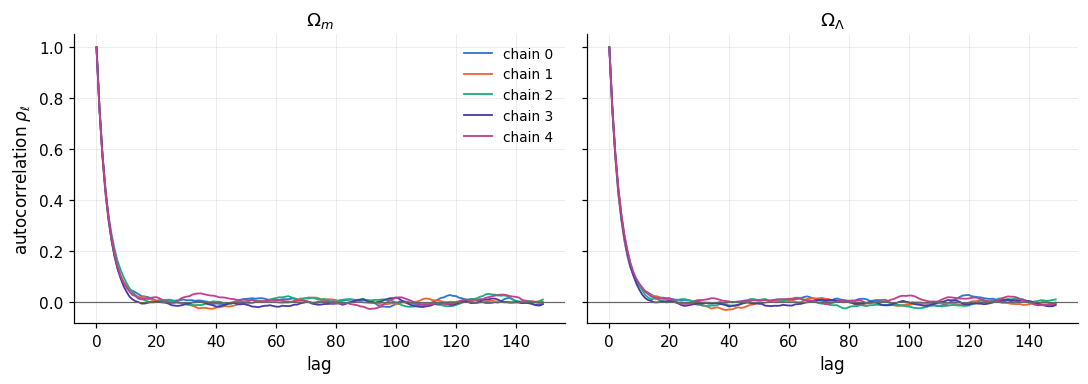

parameter     tau_int (per chain)             ESS per chain                    total ESS   MCSE(mean)
Omega_m       [7.5 7.  7.4 6.6 8.1]           [3993 4295 4050 4516 3717]           20570      0.00078
Omega_Lambda  [7.4 7.1 7.2 6.9 7.8]           [4029 4221 4154 4356 3828]           20589      0.00144

parameter       bulk-ESS  tail-ESS 5/95%  tail-ESS 16/84%
Omega_m            20494           27043            24396
Omega_Lambda       20637           26697            24073


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
MAX_LAG = 150
for p, ax in enumerate(axes):
    for i in range(N_CHAINS):
        rho = dg.autocorr(chains[i, :, p])
        ax.plot(np.arange(MAX_LAG), rho[:MAX_LAG], color=CHAIN_COLORS[i], lw=1.2,
                label=f"chain {i}")
    ax.axhline(0, color="0.4", lw=0.8)
    ax.set_xlabel("lag")
    ax.set_title(PARAM_LABELS[p])
axes[0].set_ylabel(r"autocorrelation $\rho_\ell$")
axes[0].legend()
fig.tight_layout()
FIGURES["acf"] = fig
plt.show()

print(f"{'parameter':<14}{'tau_int (per chain)':<32}{'ESS per chain':<32}{'total ESS':>10}{'MCSE(mean)':>13}")
for p, name in enumerate(PARAM_NAMES):
    taus = [dg.integrated_time(chains[i, :, p]) for i in range(N_CHAINS)]
    esss = [dg.ess(chains[i, :, p]) for i in range(N_CHAINS)]
    print(f"{name:<14}{str(np.round(taus, 1)):<32}{str(np.round(esss).astype(int)):<32}"
          f"{dg.ess(chains[:, :, p]):>10.0f}{dg.mcse(chains[:, :, p]):>13.5f}")

print(f"\n{'parameter':<14}{'bulk-ESS':>10}{'tail-ESS 5/95%':>16}{'tail-ESS 16/84%':>17}")
for p, name in enumerate(PARAM_NAMES):
    print(f"{name:<14}{dg.ess_bulk(chains[:, :, p]):>10.0f}"
          f"{dg.ess_tail(chains[:, :, p]):>16.0f}"
          f"{dg.ess_tail(chains[:, :, p], probs=(0.16, 0.84)):>17.0f}")

### 5.4 Dunkley test (slide 24)

Fit $P(k)=P_0/[1+(k/k_*)^\alpha]$ to each chain; converged if $j_*>20$ and $r<0.01$. Since $r=1/N_{\rm eff}$, $r\cdot$ESS should be $O(1)$, which is used to flag degenerate fits.

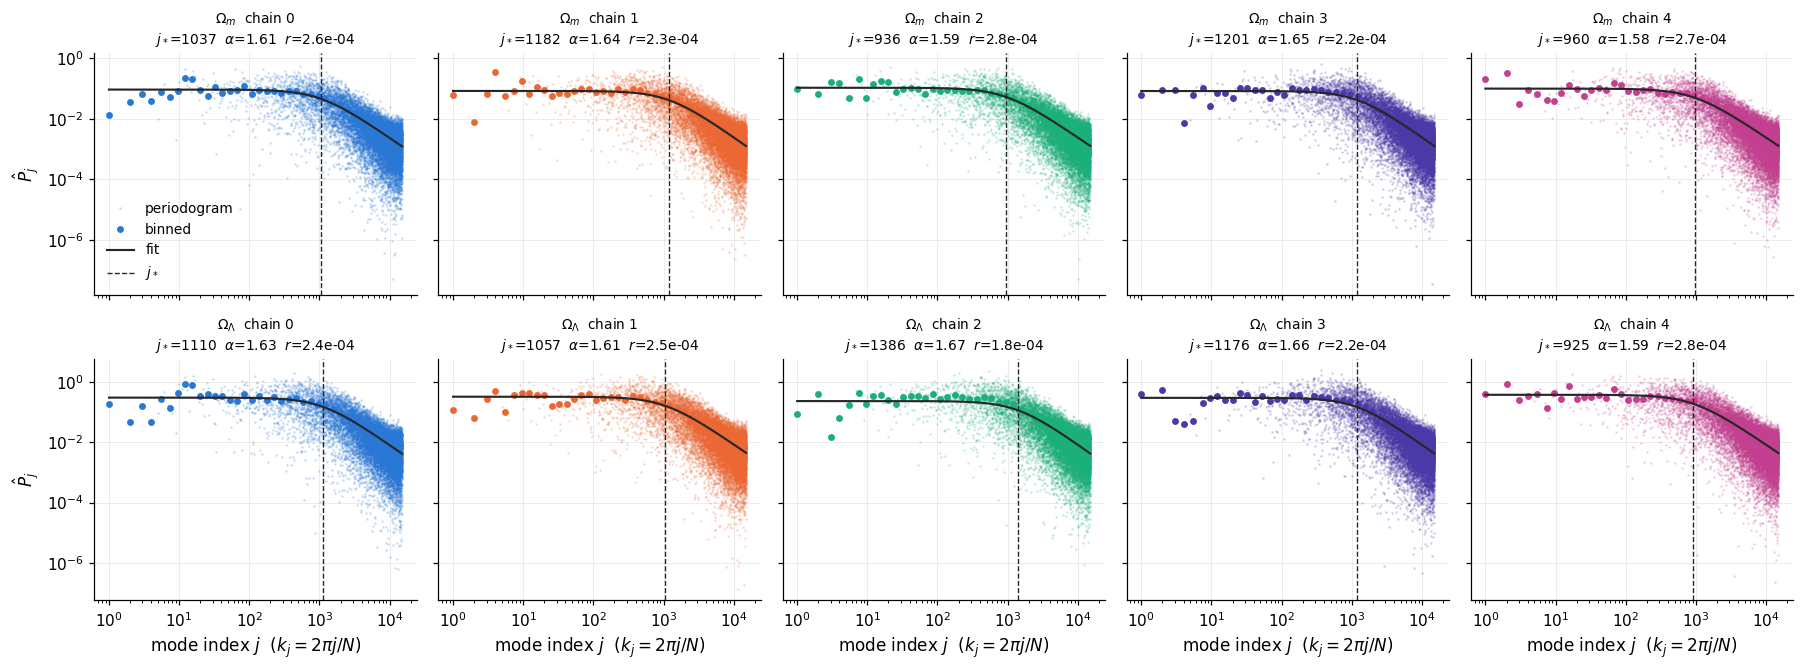

param         chain       j*   alpha          r   j*>20  r<0.01   r*ESS   converged   fit
Omega_m           0   1037.1    1.61   2.56e-04    True    True    1.02   True        ok
Omega_m           1   1182.4    1.64   2.25e-04    True    True    0.97   True        ok
Omega_m           2    935.7    1.59   2.84e-04    True    True    1.15   True        ok
Omega_m           3   1201.0    1.65   2.16e-04    True    True    0.97   True        ok
Omega_m           4    959.7    1.58   2.70e-04    True    True    1.01   True        ok
Omega_Lambda      0   1110.2    1.63   2.41e-04    True    True    0.97   True        ok
Omega_Lambda      1   1056.5    1.61   2.52e-04    True    True    1.06   True        ok
Omega_Lambda      2   1386.3    1.67   1.79e-04    True    True    0.74   True        ok
Omega_Lambda      3   1176.2    1.66   2.22e-04    True    True    0.97   True        ok
Omega_Lambda      4    925.4    1.59   2.85e-04    True    True    1.09   True        ok

Dunkley flags (j*>2

In [33]:
dunkley = [[dg.dunkley_test(chains[i, :, p]) for i in range(N_CHAINS)]
           for p in range(2)]

# fit sanity check: r = 1/N_eff by definition, so r * ESS should be O(1);
# alpha stuck at its lower bound (0) means the fit missed the spectrum knee
def fit_suspect(res, ess_chain):
    return res.alpha < 0.05 or not (0.2 < res.r * ess_chain < 5.0)


fig, axes = plt.subplots(2, N_CHAINS, figsize=(3.3 * N_CHAINS, 6.2),
                         sharex=True, sharey="row")
for p in range(2):
    for i in range(N_CHAINS):
        ax, res = axes[p, i], dunkley[p][i]
        c = CHAIN_COLORS[i]
        ax.loglog(res.j, res.power, ".", ms=1.5, color=c, alpha=0.18, rasterized=True,
                  label="periodogram")
        ax.loglog(res.j_binned, res.power_binned, "o", ms=3.5, color=c, label="binned")
        jj = np.logspace(0, np.log10(res.j[-1]), 300)
        ax.loglog(jj, res.fit(jj), "-", color="0.15", lw=1.4, label="fit")
        ax.axvline(res.jstar, color="0.15", ls="--", lw=0.9, label=r"$j_*$")
        bad = fit_suspect(res, dg.ess(chains[i, :, p]))
        ax.set_title(f"{PARAM_LABELS[p]}  chain {i}" + ("  [fit suspect]" if bad else "") + "\n"
                     rf"$j_*$={res.jstar:.0f}  $\alpha$={res.alpha:.2f}  $r$={res.r:.1e}",
                     fontsize=9, color="#c0392b" if bad else "black")
        ax.grid(alpha=0.25)
for ax in axes[-1]:
    ax.set_xlabel("mode index $j$  ($k_j = 2\\pi j/N$)")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\hat P_j$")
axes[0, 0].legend(loc="lower left")
fig.tight_layout()
FIGURES["dunkley_spectra"] = fig
plt.show()

print(f"{'param':<14}{'chain':>5}{'j*':>9}{'alpha':>8}{'r':>11}{'j*>20':>8}{'r<0.01':>8}"
      f"{'r*ESS':>8}   converged   fit")
suspect = []
for p, name in enumerate(PARAM_NAMES):
    for i in range(N_CHAINS):
        r = dunkley[p][i]
        r_ess = r.r * dg.ess(chains[i, :, p])
        bad = fit_suspect(r, dg.ess(chains[i, :, p]))
        if bad:
            suspect.append((name, i))
        print(f"{name:<14}{i:>5}{r.jstar:>9.1f}{r.alpha:>8.2f}{r.r:>11.2e}"
              f"{str(r.jstar_ok):>8}{str(r.r_ok):>8}{r_ess:>8.2f}   {str(r.converged):<9}   "
              f"{'SUSPECT' if bad else 'ok'}")

print("\nDunkley flags (j*>20 and r<0.01) pass for all chains/parameters:",
      all(dunkley[p][i].converged for p in range(2) for i in range(N_CHAINS)))
if suspect:
    print("WARNING: degenerate fit (alpha at bound and/or r*ESS not O(1)) in:", suspect)
    print("         j*, alpha and r are unreliable there; use 1/ESS "
          "(section 5.3) as the estimate of r.")
else:
    print("all fits pass the sanity check (r*ESS = O(1)).")

### 5.5 Summary table

The Dunkley columns come from chain 0 only; see 5.4 for all chains.

In [34]:
rows = dg.summary(chains, PARAM_NAMES)

hdr = (f"{'param':<14}{'mean':>9}{'std':>9}{'Rhat':>9}{'rank-Rhat':>11}{'fold-Rhat':>11}"
       f"{'ESS':>9}{'bulk-ESS':>10}{'tail-ESS':>10}{'MCSE':>10}{'j*':>9}{'r':>11}  Dunkley")
print(hdr)
print("-" * len(hdr))
for r in rows:
    print(f"{r['name']:<14}{r['mean']:>9.4f}{r['std']:>9.4f}{r['split_rhat']:>9.4f}"
          f"{r['rank_rhat']:>11.4f}{r['folded_rhat']:>11.4f}{r['ess']:>9.0f}"
          f"{r['ess_bulk']:>10.0f}{r['ess_tail']:>10.0f}{r['mcse']:>10.5f}"
          f"{r['dunkley_jstar']:>9.1f}{r['dunkley_r']:>11.2e}  {r['dunkley_converged']}")

for p, name in enumerate(PARAM_NAMES):
    if (name, 0) in suspect:
        print(f"\nWARNING: the Dunkley fit of chain 0 for {name} is suspect (section 5.4); "
              f"j* and r above are unreliable.")

param              mean      std     Rhat  rank-Rhat  fold-Rhat      ESS  bulk-ESS  tail-ESS      MCSE       j*          r  Dunkley
-----------------------------------------------------------------------------------------------------------------------------------
Omega_m          0.2784   0.1113   1.0003     1.0003     1.0002    20570     20494     27043   0.00078   1037.1   2.56e-04  True
Omega_Lambda     0.6547   0.2071   1.0001     1.0001     1.0003    20589     20637     26697   0.00144   1110.2   2.41e-04  True


## 6. Results

68% and 95% HPD contours of the pooled chains, with the flat line $\Omega_m+\Omega_\Lambda=1$ for reference (not imposed).

pooled samples: (150000, 2)


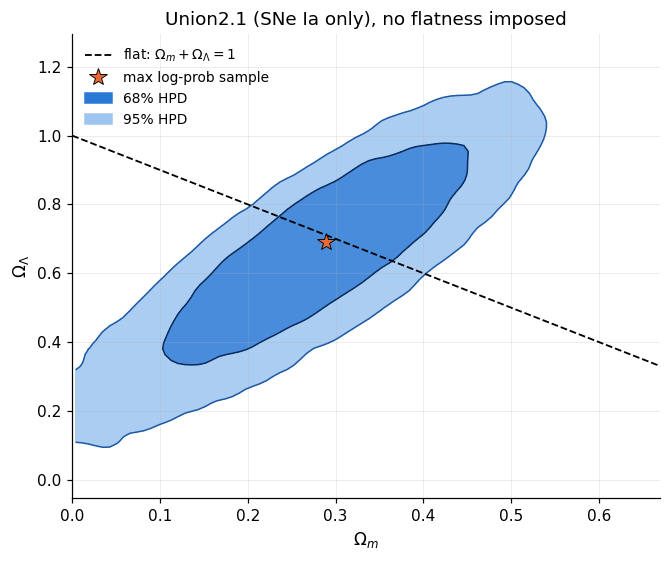

In [35]:
samples = chains.reshape(-1, 2)
om, ol = samples[:, 0], samples[:, 1]
print("pooled samples:", samples.shape)

i_best = np.unravel_index(np.argmax(log_probs), log_probs.shape)
theta_map = chains[i_best]
lp_map = log_probs[i_best]

LEVELS = (0.68, 0.95)
xc, yc, dens, thr = contour_levels_2d(om, ol, LEVELS, bins=90, smooth=1.5)
lv = np.sort(thr)

fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.contourf(xc, yc, dens, levels=[lv[0], lv[1], dens.max() * 1.01],
            colors=["#9ec5f0", "#2a78d6"], alpha=0.85)
ax.contour(xc, yc, dens, levels=lv, colors=["#1d5aa3", "#0b2d5c"], linewidths=1.0)

xx = np.linspace(0.0, 2.0, 200)
ax.plot(xx, 1.0 - xx, "k--", lw=1.2, label=r"flat: $\Omega_m+\Omega_\Lambda=1$")
ax.plot(*theta_map, marker="*", ms=12, color="#eb6834", mec="k", mew=0.6, ls="none",
        label="max log-prob sample")

handles, labels = ax.get_legend_handles_labels()
handles += [Patch(color="#2a78d6", label="68% HPD"), Patch(color="#9ec5f0", label="95% HPD")]

pad = 0.05
ax.set_xlim(max(BOUNDS[0][0], np.percentile(om, 0.05) - pad), np.percentile(om, 99.95) + pad)
ax.set_ylim(max(BOUNDS[1][0], np.percentile(ol, 0.05) - pad), np.percentile(ol, 99.95) + pad)
ax.set_xlabel(r"$\Omega_m$")
ax.set_ylabel(r"$\Omega_\Lambda$")
ax.set_title("Union2.1 (SNe Ia only), no flatness imposed")
ax.legend(handles=handles, loc="upper left")
fig.tight_layout()
FIGURES["contours"] = fig
plt.show()

### Corner plot

Marginal posteriors on the diagonal, joint 68% / 95% HPD contours below it. Each title gives the median and the equal-tailed 68% interval (dashed lines on the histograms), computed on the pooled, unthinned chains exactly as in the marginal constraints below.

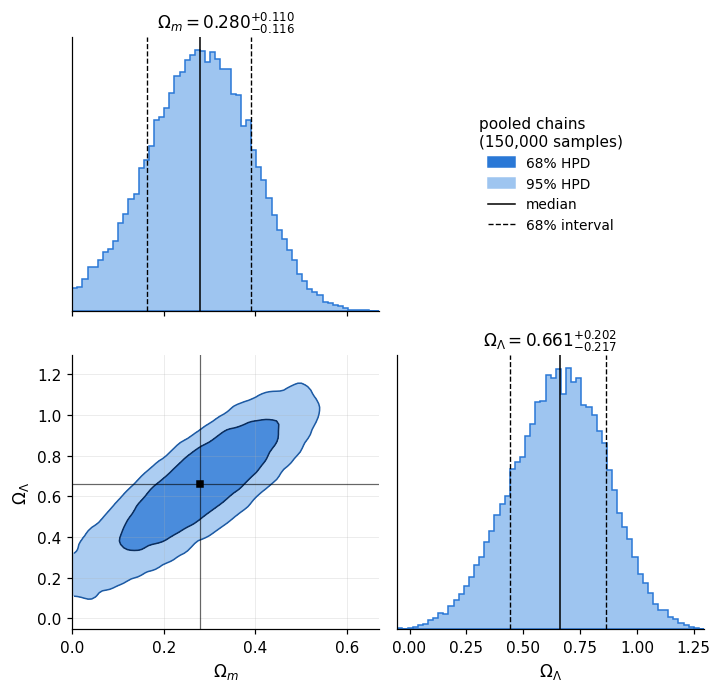

In [36]:
TEX_NAMES = [r"\Omega_m", r"\Omega_\Lambda"]
COLOR, COLOR_LIGHT = "#2a78d6", "#9ec5f0"

pad_c = 0.05
lims = [(max(BOUNDS[p][0], np.percentile(samples[:, p], 0.05) - pad_c),
         np.percentile(samples[:, p], 99.95) + pad_c) for p in range(2)]
stats = [credible_interval(samples[:, p], 0.68) for p in range(2)]     # (median, lo, hi)

xc_c, yc_c, dens_c, thr_c = contour_levels_2d(samples[:, 0], samples[:, 1], LEVELS,
                                              bins=90, smooth=1.5)
lv_c = np.sort(thr_c)

fig, axes = plt.subplots(2, 2, figsize=(6.6, 6.4), sharex="col")

# --- diagonal: marginal posteriors with median and 68% interval -------------
for p, ax in enumerate([axes[0, 0], axes[1, 1]]):
    med, lo, hi = stats[p]
    ax.hist(samples[:, p], bins=60, range=lims[p], density=True, histtype="stepfilled",
            color=COLOR_LIGHT, edgecolor=COLOR, lw=1.0)
    ax.axvline(med, color="k", lw=1.0)
    for edge in (lo, hi):
        ax.axvline(edge, color="k", ls="--", lw=0.9)
    ax.set_title(rf"${TEX_NAMES[p]} = {med:.3f}^{{+{hi - med:.3f}}}_{{-{med - lo:.3f}}}$",
                 fontsize=11)
    ax.set_yticks([])
    ax.set_xlim(*lims[p])
    ax.grid(False)

# --- lower-left: joint posterior ---------------------------------------------
ax = axes[1, 0]
ax.contourf(xc_c, yc_c, dens_c, levels=[lv_c[0], lv_c[1], dens_c.max() * 1.01],
            colors=[COLOR_LIGHT, COLOR], alpha=0.85)
ax.contour(xc_c, yc_c, dens_c, levels=lv_c, colors=["#1d5aa3", "#0b2d5c"], linewidths=1.0)
ax.axvline(stats[0][0], color="k", lw=0.8, alpha=0.6)
ax.axhline(stats[1][0], color="k", lw=0.8, alpha=0.6)
ax.plot(stats[0][0], stats[1][0], "ks", ms=4)
ax.set_xlim(*lims[0])
ax.set_ylim(*lims[1])
ax.set_xlabel(PARAM_LABELS[0])
ax.set_ylabel(PARAM_LABELS[1])

# --- upper-right: legend --------------------------------------------------------
ax = axes[0, 1]
ax.axis("off")
ax.legend(handles=[Patch(color=COLOR, label="68% HPD"),
                   Patch(color=COLOR_LIGHT, label="95% HPD"),
                   plt.Line2D([], [], color="k", lw=1.0, label="median"),
                   plt.Line2D([], [], color="k", lw=0.9, ls="--", label="68% interval")],
          loc="center", title=f"pooled chains\n({samples.shape[0]:,} samples)")

axes[1, 1].set_xlabel(PARAM_LABELS[1])
axes[1, 1].tick_params(labelbottom=True)
fig.tight_layout()
FIGURES["corner"] = fig
plt.show()

### Marginal constraints

Median and 68% interval; $\Omega_k=1-\Omega_m-\Omega_\Lambda$ is computed per sample.

In [37]:
omega_k = 1.0 - om - ol
marg = {r"Omega_m": om, r"Omega_Lambda": ol, r"Omega_k = 1 - Om - OL": omega_k}

print(f"{'parameter':<24}{'median':>9}{'-':>9}{'+':>9}     68% interval")
for name, x in marg.items():
    med, lo, hi = credible_interval(x, 0.68)
    print(f"{name:<24}{med:>9.3f}{med - lo:>9.3f}{hi - med:>9.3f}     [{lo:.3f}, {hi:.3f}]")

print(f"\nP(Omega_k < 0) = {np.mean(omega_k < 0):.3f}   (closed)")
print(f"P(Omega_k > 0) = {np.mean(omega_k > 0):.3f}   (open)")

parameter                  median        -        +     68% interval
Omega_m                     0.280    0.116    0.110     [0.164, 0.391]
Omega_Lambda                0.661    0.217    0.202     [0.444, 0.863]
Omega_k = 1 - Om - OL       0.058    0.300    0.324     [-0.242, 0.382]

P(Omega_k < 0) = 0.429   (closed)
P(Omega_k > 0) = 0.571   (open)


### Zero-point check

$\hat M=B/E$ (`best_fit_M`) at the maximum-density sample should be small for $H_0=70$.

In [38]:
mu_map = posterior.model(theta_map)
M_hat = data.best_fit_M(mu_map)

print(f"maximum-density point: Omega_m = {theta_map[0]:.3f}, "
      f"Omega_Lambda = {theta_map[1]:.3f}   (log_prob = {lp_map:.2f})")
print(f"best_fit_M (H0={H0:g}) = {M_hat:+.4f} mag")

maximum-density point: Omega_m = 0.289, Omega_Lambda = 0.690   (log_prob = -275.25)
best_fit_M (H0=70) = +0.0108 mag


## 7. Save figures

PNGs are written to `notebooks/figures/`.

In [39]:
FIG_DIR.mkdir(parents=True, exist_ok=True)
for name, fig in FIGURES.items():
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path)
    assert path.exists() and path.stat().st_size > 0
    print(f"saved: {path.relative_to(ROOT)}  ({path.stat().st_size / 1024:.0f} kB)")

saved: notebooks/figures/burnin.png  (242 kB)
saved: notebooks/figures/traces.png  (361 kB)
saved: notebooks/figures/acf.png  (70 kB)
saved: notebooks/figures/dunkley_spectra.png  (560 kB)
saved: notebooks/figures/contours.png  (87 kB)
saved: notebooks/figures/corner.png  (73 kB)
